In [1]:
import pandas as pd
import numpy as np
import os, warnings, shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from tqdm import tqdm

%matplotlib inline
warnings.filterwarnings('ignore')

# Global Configuration
INPUT_FILE = '/Users/whd/Downloads/gdshyc/featuredata.xlsx'
SAVE_DIR = '/Users/whd/Downloads/gdshyc/result'
TARGET_COL_NAME = 'η（mV)'  
RANDOM_STATE = 0

# Set plotting style
plt.rcParams.update({
    'font.sans-serif': ['Arial Unicode MS', 'SimHei', 'DejaVu Sans'], 
    'axes.unicode_minus': False, 
    'figure.dpi': 300
})
if not os.path.exists(SAVE_DIR): os.makedirs(SAVE_DIR)

In [2]:
# 1. Data Loading
def load_and_clean_data(input_path, target_col):
    df = pd.read_excel(input_path, header=1)
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found.")
        
    target_idx = df.columns.get_loc(target_col)
    feature_cols = df.columns[target_idx + 1:].tolist()
    
    # Convert to numeric and drop rows with missing values
    df_clean = df[[target_col] + feature_cols].apply(pd.to_numeric, errors='coerce').dropna()
    
    print(f"Data Loading")
    print(f"Cleaned Samples: {len(df_clean)}")
    print(f"Original Feature Count: {len(feature_cols)}\n")
    return df_clean[feature_cols], df_clean[target_col]

X_clean, y_clean = load_and_clean_data(INPUT_FILE, TARGET_COL_NAME)

Data Loading
Cleaned Samples: 56
Original Feature Count: 15



Pearson Correlation Filtering
[Kept Features] (14): 
['Ф', 'χ', 'Am', 'Δχ', 'Tm', 'Im', 'ΔФ', 'ΔHBE', 'OHBE', 'ΔHmix', 'δ', 'HBE', 'd', 'ΔOHBE']

[Dropped Features] (1) due to high correlation: 
['VEC']


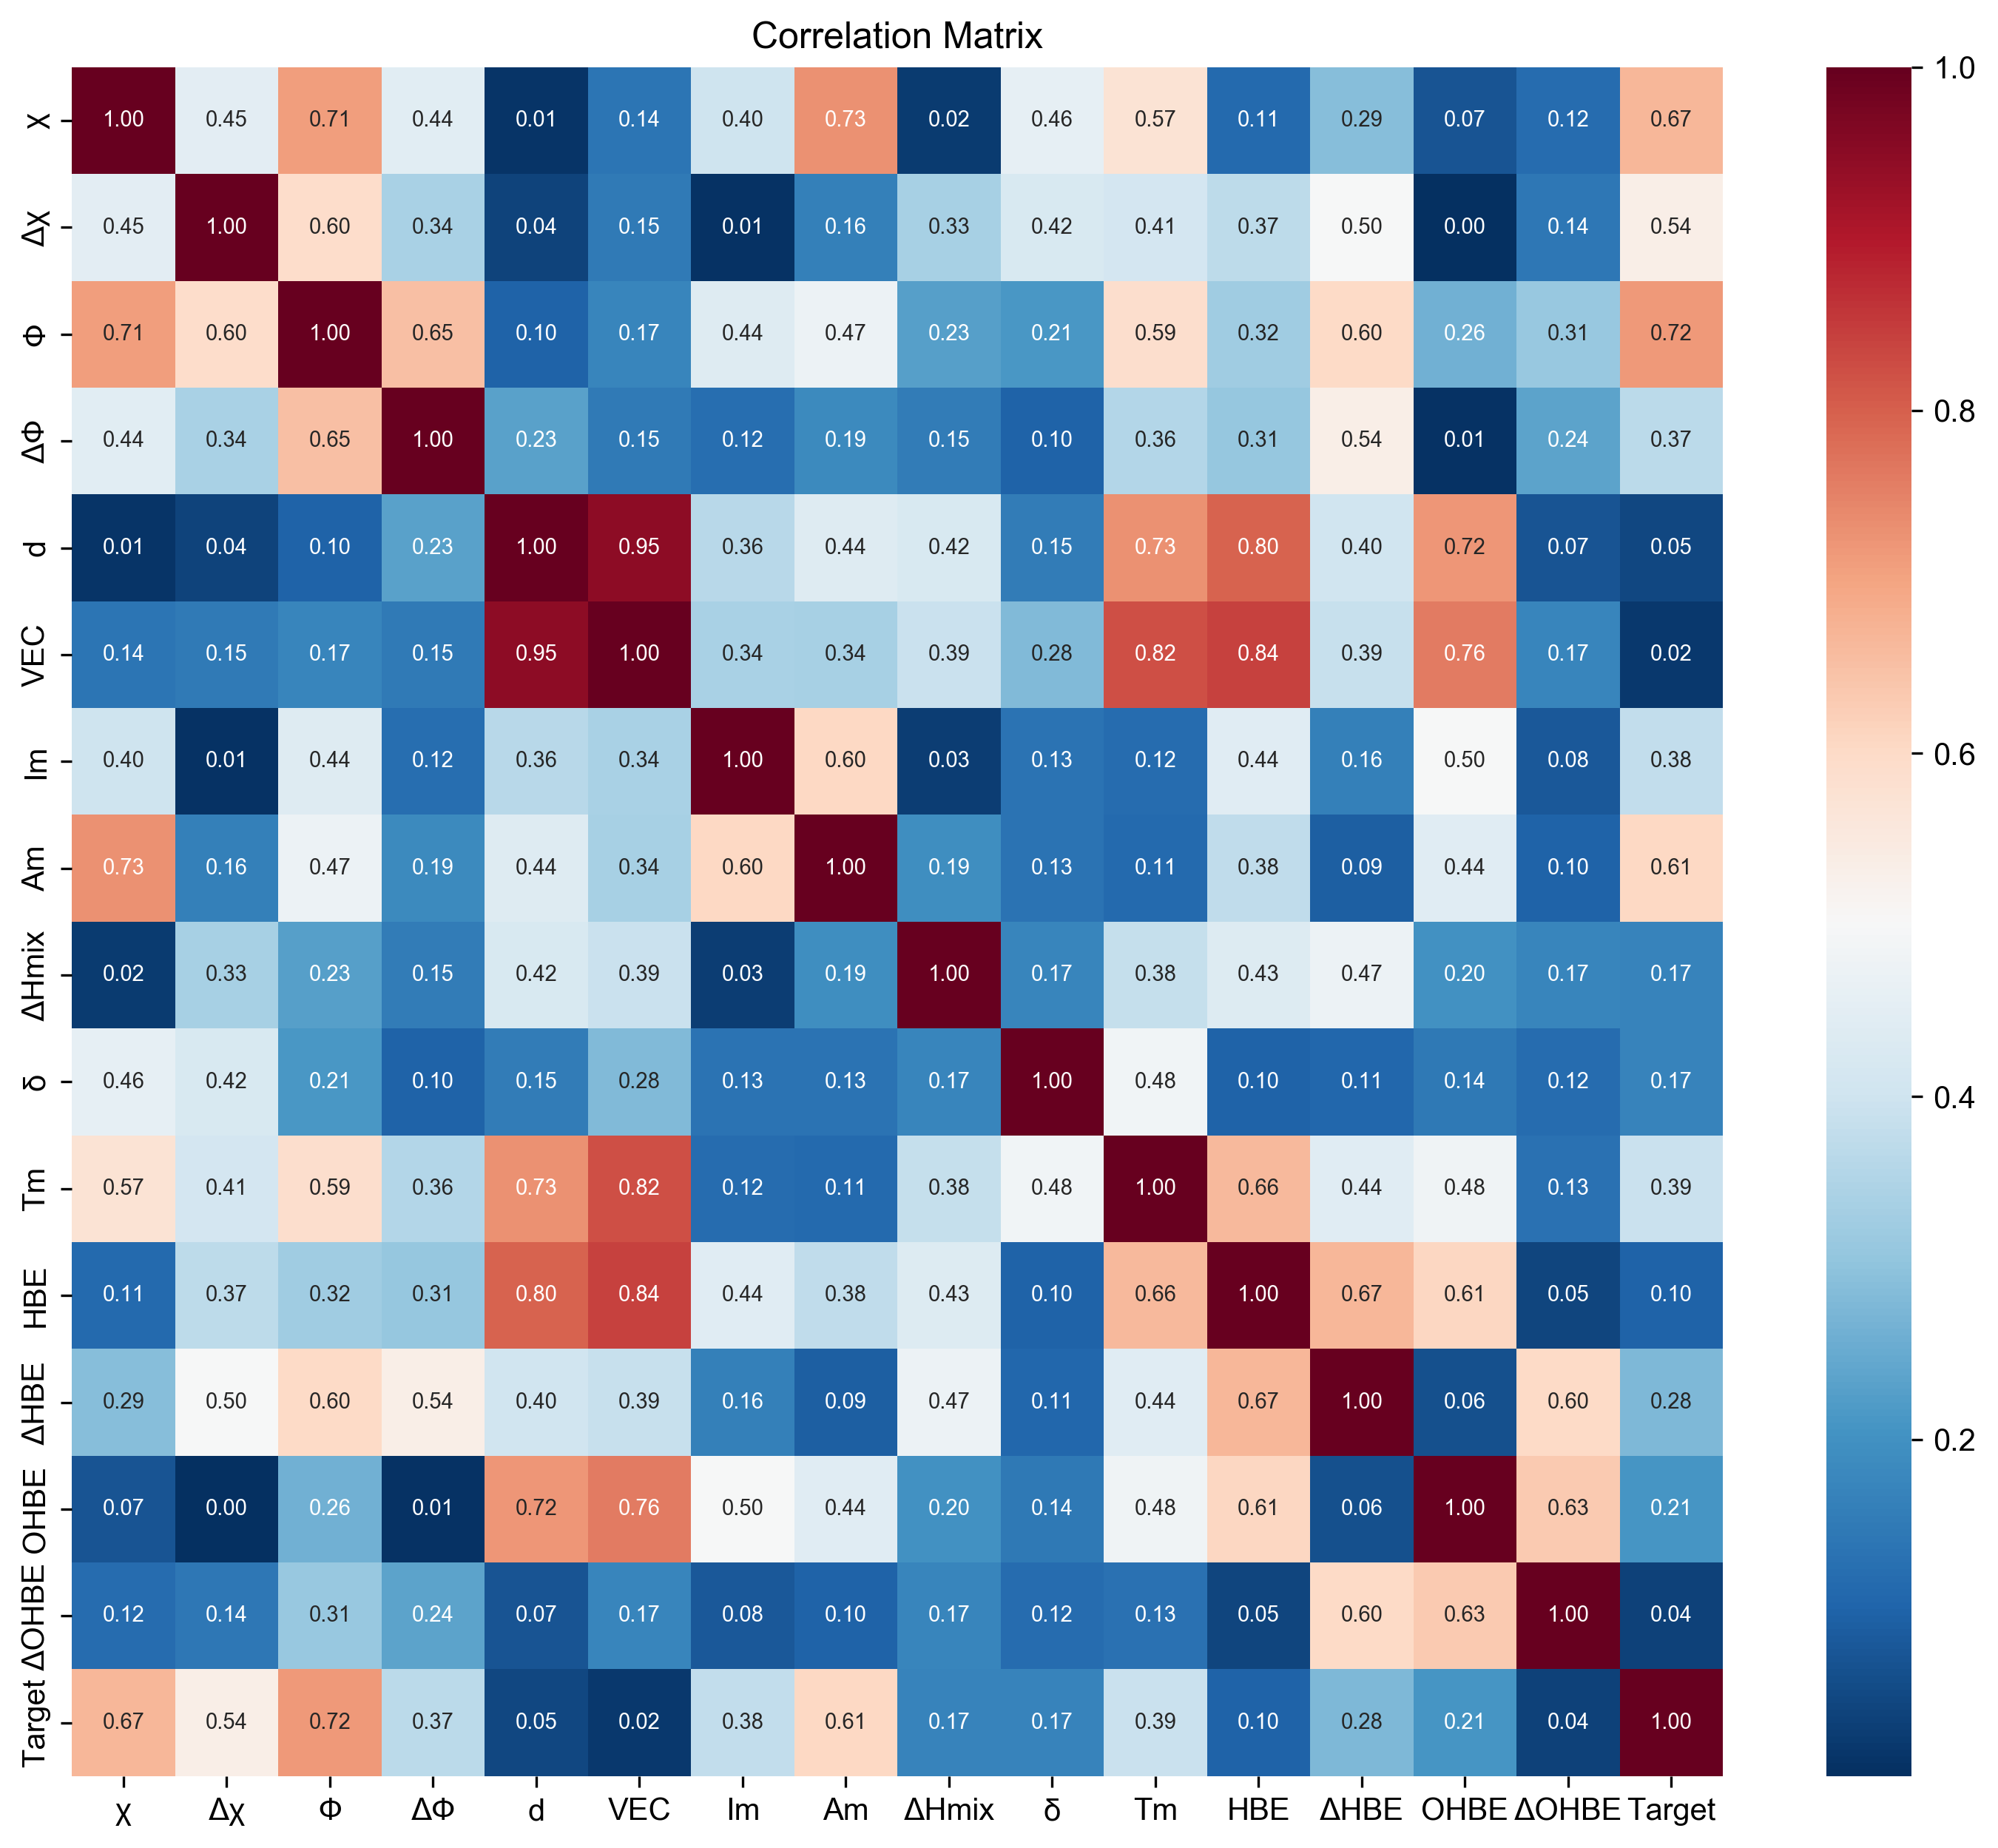

In [3]:
# 2. Pearson Correlation Filtering
def pearson_correlation_filter(X, y, threshold=0.8):
    print("Pearson Correlation Filtering")
    
    # Merge feature and target for full correlation matrix
    full_df = pd.concat([X, y.rename('Target')], axis=1)
    corr_matrix = full_df.corr().abs()
    
    # Sort features by their correlation with the target
    target_corr = corr_matrix['Target'].drop('Target').sort_values(ascending=False)
    
    # Filtering Logic: Remove highly redundant features
    kept_feats, dropped_pearson = [], []
    for feat in target_corr.index:
        # If the feature is highly correlated with any already kept feature, drop it
        if any(corr_matrix.loc[feat, k] > threshold for k in kept_feats):
            dropped_pearson.append(feat)
        else:
            kept_feats.append(feat)
    
    # Output Results
    print(f"[Kept Features] ({len(kept_feats)}): \n{kept_feats}")
    print(f"\n[Dropped Features] ({len(dropped_pearson)}) due to high correlation: \n{dropped_pearson}")
    
    # Visualization
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', annot_kws={'size': 7})
    plt.title("Correlation Matrix")
    plt.savefig(os.path.join(SAVE_DIR, 'correlation_matrix.png'), bbox_inches='tight')
    plt.show()
    
    return X[kept_feats], dropped_pearson

X_step1, dropped_pearson = pearson_correlation_filter(X_clean, y_clean)


SHAP Coarse Selection (CV-based)


Calculating CV SHAP Values: 100%|███████████████| 25/25 [00:01<00:00, 15.48it/s]



[CV-Averaged SHAP Importance Ranking]:
Am       33.897865
χ        27.463143
Δχ       24.396049
Ф        15.460085
OHBE      5.937668
Im        5.156281
ΔФ        4.878891
ΔHBE      4.823571
Tm        3.847723
d         3.023605
ΔHmix     2.957971
HBE       2.560288
δ         1.752729
ΔOHBE     1.133163

[Final Kept Features] (11): ['Am', 'χ', 'Δχ', 'Ф', 'OHBE', 'Im', 'ΔФ', 'ΔHBE', 'Tm', 'd', 'ΔHmix']
[Dropped by SHAP]: ['HBE', 'ΔOHBE', 'δ']


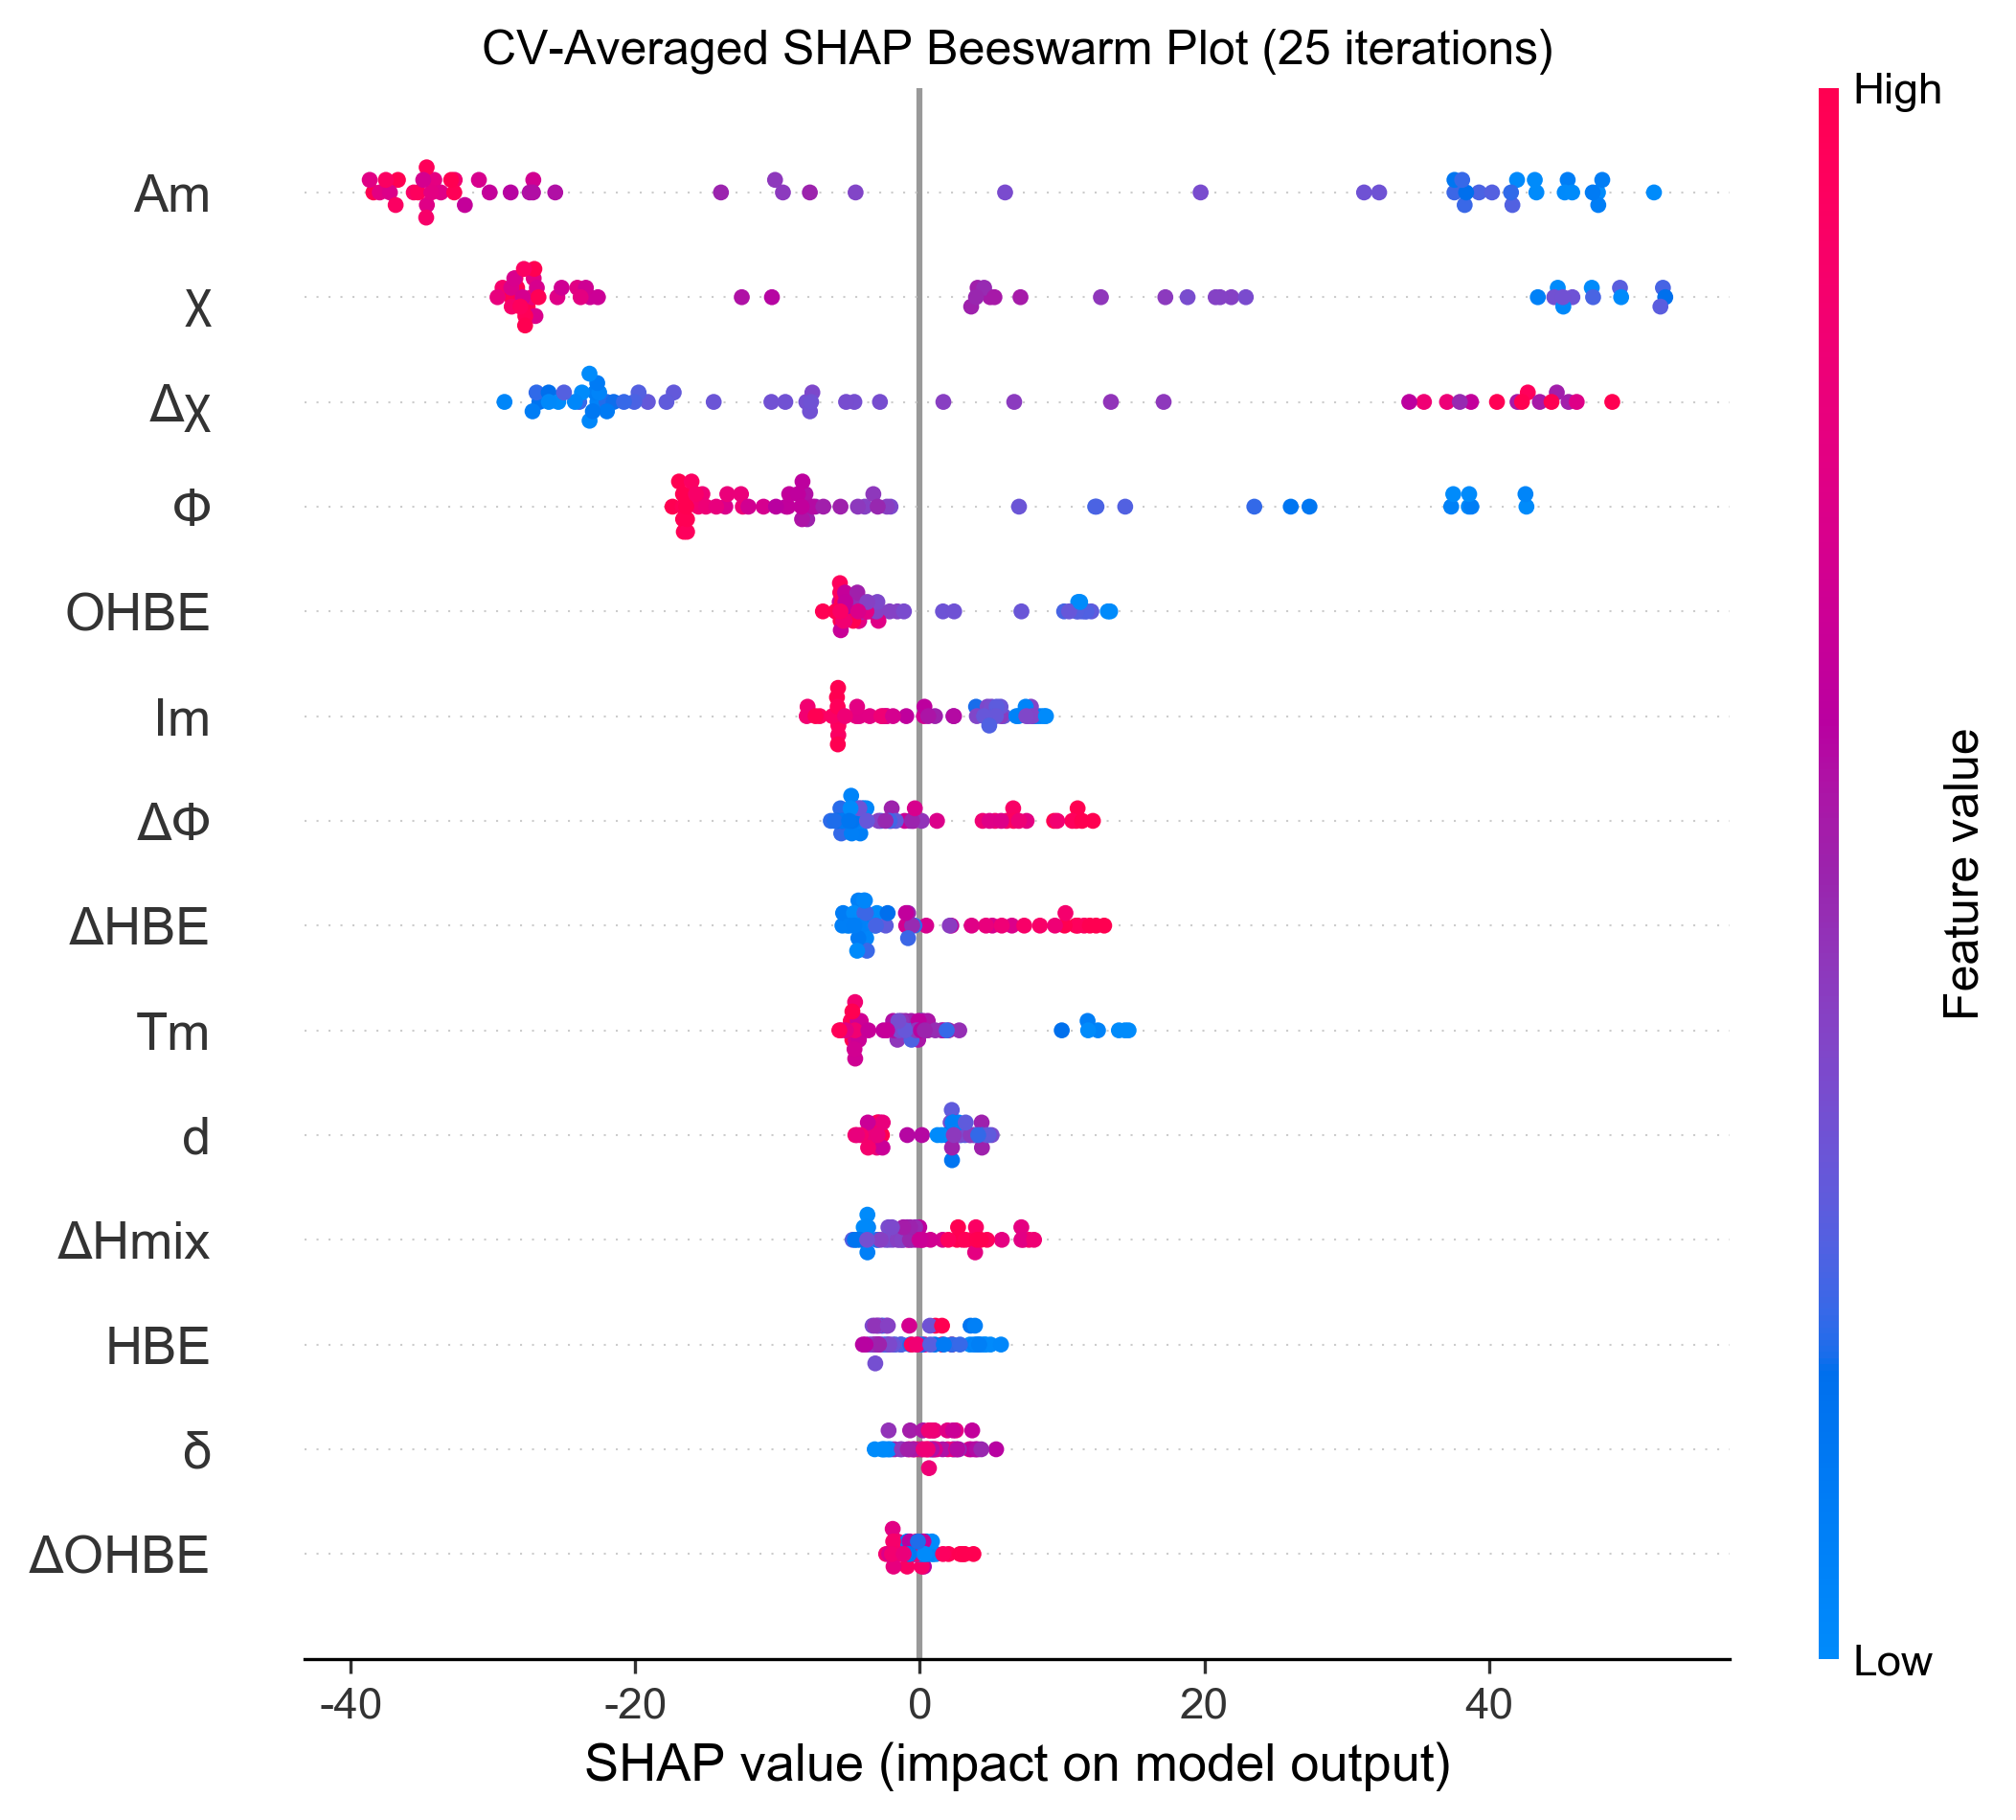

In [5]:
# 3. SHAP Coarse Selection 
def shap_coarse_selection(X, y, percent=0.8):
    print("\nSHAP Coarse Selection (CV-based)")
    rf_params = dict(n_estimators=100, max_depth=4, max_features='sqrt', 
                     min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1)
    
    # Repeated K-Fold settings
    n_splits = 5
    n_repeats = 5
    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_STATE)
    
    # Initialize a matrix to accumulate SHAP values for each sample
    # Shape: (number of samples, number of features)
    cv_shap_values = np.zeros(X.shape)
    
    # Standardize full X for the final plot's feature values (background color)
    sc_final = StandardScaler()
    X_scaled_full = pd.DataFrame(sc_final.fit_transform(X), columns=X.columns)

    total_iterations = n_splits * n_repeats
    
    for train_idx, _ in tqdm(rkf.split(X), total=total_iterations, desc="Calculating CV SHAP Values"):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        
        # Scale based on current training fold
        sc_fold = StandardScaler().fit(X_tr)
        X_tr_scaled = sc_fold.transform(X_tr)
        
        # Train model on this fold
        model = RandomForestRegressor(**rf_params).fit(X_tr_scaled, y_tr)
        
        # Explain the full dataset using this fold's model
        # This ensures every fold contributes to the overall explanation of the data
        explainer = shap.TreeExplainer(model)
        # We transform the full X using the fold-specific scaler
        fold_shap = explainer.shap_values(sc_fold.transform(X))
        
        # Accumulate SHAP values
        cv_shap_values += fold_shap
    
    # 1. Calculate Average SHAP values across all iterations
    mean_cv_shap = cv_shap_values / total_iterations
    
    # 2. Rank features based on mean absolute SHAP values
    shap_avg_rank = pd.Series(np.abs(mean_cv_shap).mean(axis=0), index=X.columns).sort_values(ascending=False)
    print(f"\n[CV-Averaged SHAP Importance Ranking]:\n{shap_avg_rank.to_string()}")
    
    # 3. Feature Selection
    keep_num = max(1, int(len(shap_avg_rank) * percent))
    keep_feats = shap_avg_rank.index[:keep_num].tolist()
    dropped_shap = list(set(X.columns) - set(keep_feats))
    
    print(f"\n[Final Kept Features] ({len(keep_feats)}): {keep_feats}")
    print(f"[Dropped by SHAP]: {dropped_shap}")

    # 4. Generate CV-based Beeswarm Plot
    # We construct a SHAP Explanation object to use the built-in beeswarm plot
    cv_explanation = shap.Explanation(
        values=mean_cv_shap, 
        data=X_scaled_full.values, 
        feature_names=X.columns.tolist()
    )

    plt.figure(figsize=(10, 8))
    # Beeswarm plot will now use the CV-averaged SHAP values
    shap.plots.beeswarm(cv_explanation, max_display=15, show=False)
    plt.title(f"CV-Averaged SHAP Beeswarm Plot ({total_iterations} iterations)")
    plt.savefig(os.path.join(SAVE_DIR, 'shap_beeswarm_cv.png'), bbox_inches='tight')
    plt.show()
    
    return X[keep_feats], dropped_shap

# Run the updated function
X_step2, dropped_shap = shap_coarse_selection(X_step1, y_clean)